# Nigeria Road Quality Baseline (NirTIMS)

This notebook loads the NirTIMS shapefiles and runs baseline analyses:
- Condition distribution (`SURFACECON`)
- Condition vs pavement type (`PAVETYPE`)
- Problem area burden (`PATYPE`)
- Defect density per road length


In [34]:
import geopandas as gpd
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style='whitegrid')

DATA_DIR = Path('/Users/miranda/Documents/GitHub/Sentinel-FYP/data/NirTIMS Shapefiles Nov 14 2025')
DATA_DIR


PosixPath('/Users/miranda/Documents/GitHub/Sentinel-FYP/data/NirTIMS Shapefiles Nov 14 2025')

In [35]:
# List available shapefiles
sorted([p.name for p in DATA_DIR.glob('*.shp')])


['Bridges.shp',
 'BusStops.shp',
 'Causeways.shp',
 'CrossingInfra.shp',
 'Culverts.shp',
 'EducationFacilities.shp',
 'HealthFacilities.shp',
 'HolyPlaces.shp',
 'KmStones.shp',
 'Markets.shp',
 'Poles.shp',
 'ProblemAreas.shp',
 'RoadCondition.shp',
 'RoadNetwork.shp',
 'RoadPavement.shp',
 'RoadSideDrains.shp',
 'RoadSideStructures.shp',
 'Settlements.shp',
 'SpeedBreakers.shp',
 'TrafficSigns.shp']

In [3]:
# Load core layers
road_cond = gpd.read_file(DATA_DIR / 'RoadCondition.shp')
road_net = gpd.read_file(DATA_DIR / 'RoadNetwork.shp')
road_pave = gpd.read_file(DATA_DIR / 'RoadPavement.shp')
problem = gpd.read_file(DATA_DIR / 'ProblemAreas.shp')

print('RoadCondition:', road_cond.shape)
print('RoadNetwork  :', road_net.shape)
print('RoadPavement :', road_pave.shape)
print('ProblemAreas :', problem.shape)


RoadCondition: (15953, 5)
RoadNetwork  : (6196, 7)
RoadPavement : (14793, 7)
ProblemAreas : (26028, 11)


In [ ]:
# Keep essential columns
rc = road_cond[['ROADCODE', 'ROADNAME', 'SURFACECON', 'geometry']].copy()
rn = road_net[['ROADCODE', 'ROADCLASS', 'TOTALLEN', 'SHPLEN']].copy()
rp = road_pave[['ROADCODE', 'PAVETYPE', 'PAVEWIDTH', 'FORWIDTH']].copy()
pa = problem[['ROADCODE', 'PATYPE', 'PAINTERVEN', 'PALENGTH']].copy()

def norm_code(s):
    return (s.astype(str)
            .str.strip()
            .str.replace(r'\s+', '', regex=True)
            .str.upper())

for d in [rc, rn, rp, pa]:
    d['ROADCODE_N'] = norm_code(d['ROADCODE'])

rc.head()


(15953, 5)

In [ ]:
# Join RoadCondition to network and pavement info
base = rc.merge(rn.drop_duplicates('ROADCODE_N'), on='ROADCODE_N', how='left', suffixes=('', '_net'))
base = base.merge(rp.drop_duplicates('ROADCODE_N'), on='ROADCODE_N', how='left', suffixes=('', '_pave'))

base['SURFACECON'] = base['SURFACECON'].astype(str).str.strip()
base['PAVETYPE'] = base['PAVETYPE'].astype(str).str.strip()
base['ROADCLASS'] = base['ROADCLASS'].astype(str).str.strip()

base[['ROADCODE', 'SURFACECON', 'ROADCLASS', 'PAVETYPE']].head()


,ROADCODE,ROADNAME,SURFACECON,geometry,ROADCODE_N,ROADCODE_net,ROADCLASS,TOTALLEN,SHPLEN,ROADCODE_pave,PAVETYPE,PAVEWIDTH,FORWIDTH
0,2308-00182,Epete - Otubo - Otubo Anayi - Uwowo - Ogbogbo ...,Poor,"LINESTRING Z (6.81184 7.15368 NaN, 6.81184 7.1...",2308-00182,2308-00182,Trunk C Township,5.323,5.323,NaN,nan,NaN,NaN
1,2308-00182,Epete - Otubo - Otubo Anayi - Uwowo - Ogbogbo ...,Poor,"LINESTRING Z (6.81184 7.15368 NaN, 6.81184 7.1...",2308-00182,2308-00182,Trunk C Township,5.323,5.323,NaN,nan,NaN,NaN
2,2308-00183,Ayikpele - Okochobe - Etutobo - Ufugu,Poor,"LINESTRING Z (6.83822 7.1846 NaN, 6.83822 7.18...",2308-00183,2308-00183,Trunk C Township,5.738,5.738,2308-00183,EARTHEN,4,0
3,2308-00183,Ayikpele - Okochobe - Etutobo - Ufugu,Poor,"LINESTRING Z (6.85558 7.22966 NaN, 6.83822 7.1...",2308-00183,2308-00183,Trunk C Township,5.738,5.738,2308-00183,EARTHEN,4,0
4,2308-00184,Imere junction - Akpa - Ibochi - Ojofa - Ugbat...,Poor,"LINESTRING Z (6.85211 7.21882 NaN, 6.85211 7.2...",2308-00184,2308-00184,Trunk C Township,7.269,7.269,2308-00184,EARTHEN,3,0


In [6]:
# 1) Condition distribution
cond_counts = base['SURFACECON'].value_counts(dropna=False).rename_axis('SURFACECON').reset_index(name='count')
cond_counts['pct'] = (cond_counts['count'] / cond_counts['count'].sum() * 100).round(2)
cond_counts


,SURFACECON,count,pct
0,Poor,6452,40.44
1,Fair,4379,27.45
2,Very Poor,2955,18.52
3,Good,1695,10.62
4,Excellent,468,2.93
5,None,4,0.03


In [7]:
# 2) Condition vs pavement type
ct = pd.crosstab(base['PAVETYPE'], base['SURFACECON'])
ct_pct = pd.crosstab(base['PAVETYPE'], base['SURFACECON'], normalize='index') * 100

display(ct)
display(ct_pct.round(2))


SURFACECON,Excellent,Fair,Good,None,Poor,Very Poor
PAVETYPE,,,,,,
ASPHALT CONCRETE,226,649,907,1,903,329
CONCRETE,3,25,14,0,49,25
DBST,38,144,81,1,179,138
EARTHEN,161,3067,574,2,4804,2155
GRAVEL,28,292,81,0,341,221
None,0,2,0,0,1,0
OTTA SEAL,0,2,1,0,4,1
SBST,6,147,29,0,96,61
STONE PAVEMENT,5,28,3,0,27,13


SURFACECON,Excellent,Fair,Good,None,Poor,Very Poor
PAVETYPE,,,,,,
ASPHALT CONCRETE,7.50,21.53,30.08,0.03,29.95,10.91
CONCRETE,2.59,21.55,12.07,0.00,42.24,21.55
DBST,6.54,24.78,13.94,0.17,30.81,23.75
EARTHEN,1.50,28.50,5.33,0.02,44.63,20.02
GRAVEL,2.91,30.32,8.41,0.00,35.41,22.95
None,0.00,66.67,0.00,0.00,33.33,0.00
OTTA SEAL,0.00,25.00,12.50,0.00,50.00,12.50
SBST,1.77,43.36,8.55,0.00,28.32,17.99
STONE PAVEMENT,6.58,36.84,3.95,0.00,35.53,17.11


In [8]:
# 3) Problem area counts by type
pa_counts = pa['PATYPE'].value_counts(dropna=False).rename_axis('PATYPE').reset_index(name='count')
pa_counts['pct'] = (pa_counts['count'] / pa_counts['count'].sum() * 100).round(2)
pa_counts


,PATYPE,count,pct
0,Erosion,13385,51.43
1,Waterlogging,11218,43.10
2,Landslide,1425,5.47


In [9]:
# 4) Defect density by road (problem points per km)
# Use SHPLEN if numeric and valid; fallback to geometry length in degrees converted approx if unavailable
road_len = rc[['ROADCODE_N', 'geometry']].copy()
road_len['geom_len_deg'] = road_len.geometry.length

net_len = rn[['ROADCODE_N', 'SHPLEN', 'TOTALLEN']].copy()
for c in ['SHPLEN', 'TOTALLEN']:
    net_len[c] = pd.to_numeric(net_len[c], errors='coerce')

road_len = road_len.merge(net_len, on='ROADCODE_N', how='left')
# choose a length field
road_len['len_km'] = road_len['SHPLEN']
road_len.loc[(road_len['len_km'].isna()) | (road_len['len_km'] <= 0), 'len_km'] = road_len['TOTALLEN']

# problem count per road
prob_n = pa.groupby('ROADCODE_N').size().rename('problem_n').reset_index()
dens = road_len[['ROADCODE_N', 'len_km']].drop_duplicates('ROADCODE_N').merge(prob_n, on='ROADCODE_N', how='left')
dens['problem_n'] = dens['problem_n'].fillna(0)
dens['len_km'] = pd.to_numeric(dens['len_km'], errors='coerce')
dens = dens[dens['len_km'] > 0].copy()
dens['problems_per_10km'] = dens['problem_n'] / dens['len_km'] * 10

dens[['problem_n', 'len_km', 'problems_per_10km']].describe()


/var/folders/vs/7b7k7q7s1v19prbwdzphbqm00000gn/T/ipykernel_54417/1502589486.py:4: UserWarning: Geometry is in a geographic CRS. Results from 'length' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  road_len['geom_len_deg'] = road_len.geometry.length


,problem_n,len_km,problems_per_10km
count,4573.000000,4573.000000,4573.000000
mean,5.538159,5.939812,25.284480
std,10.262122,7.073822,304.921272
min,0.000000,0.002000,0.000000
25%,0.000000,1.628000,0.000000
50%,2.000000,3.758000,5.147012
75%,6.000000,7.697000,15.717092
max,148.000000,110.444000,16000.000000


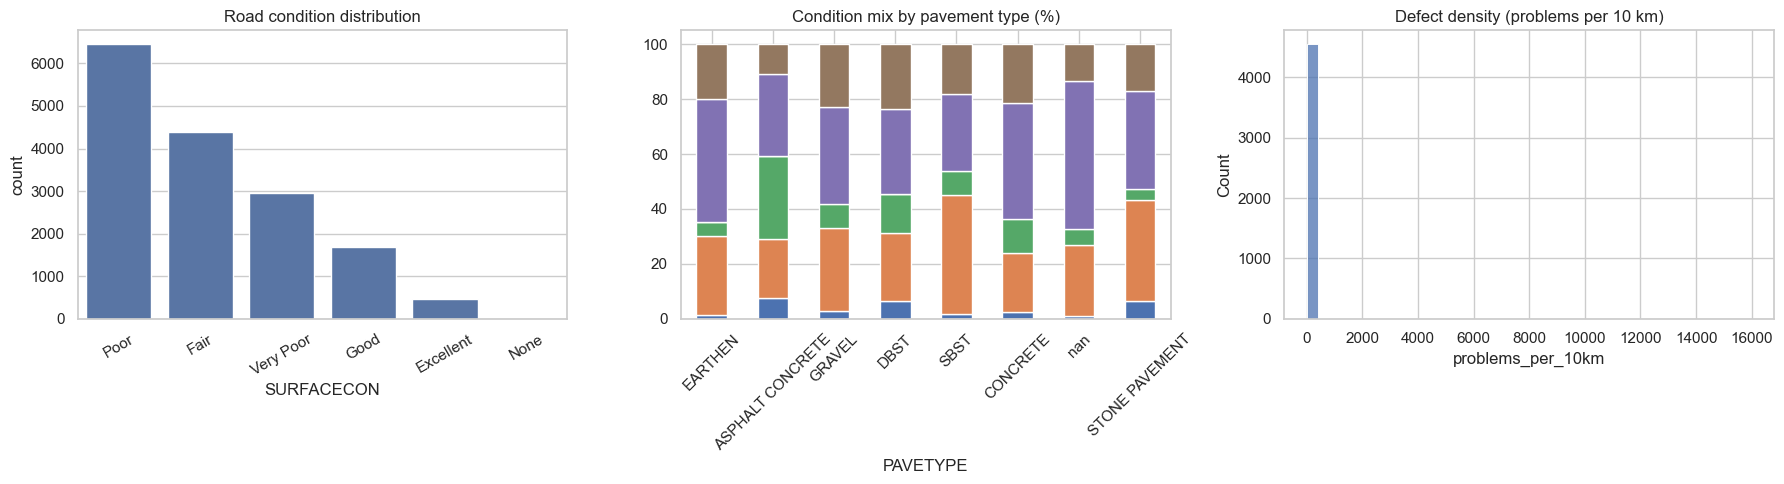

In [10]:
# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=cond_counts, x='SURFACECON', y='count', ax=axes[0])
axes[0].set_title('Road condition distribution')
axes[0].tick_params(axis='x', rotation=30)

top_pave = ct.sum(axis=1).sort_values(ascending=False).head(8).index
ct_top = ct_pct.loc[top_pave] if len(top_pave) else ct_pct
ct_top.plot(kind='bar', stacked=True, ax=axes[1], legend=False)
axes[1].set_title('Condition mix by pavement type (%)')
axes[1].tick_params(axis='x', rotation=45)

sns.histplot(dens['problems_per_10km'], bins=40, ax=axes[2])
axes[2].set_title('Defect density (problems per 10 km)')

plt.tight_layout()
plt.show()


## Next steps
- Join `RoadSideDrains`, `Culverts`, and `Bridges` by `ROADCODE_N` to explain waterlogging and erosion risk.
- Build a binary target (`Poor/Very Poor` vs `Good/Fair/Excellent`) for predictive baseline modeling.
- Add state/region boundary layer to compute regional summaries and hotspots.


In [11]:
# Step 1 — Join drains, culverts, bridges to road-level table (ROADCODE_N)

# Load extra infrastructure layers
dr = gpd.read_file(DATA_DIR / "RoadSideDrains.shp")
cu = gpd.read_file(DATA_DIR / "Culverts.shp")
br = gpd.read_file(DATA_DIR / "Bridges.shp")

for d in [dr, cu, br]:
    d["ROADCODE_N"] = norm_code(d["ROADCODE"])

# Aggregate per road
dr_agg = (
    dr.groupby("ROADCODE_N")
    .agg(
        drains_n=("ROADCODE_N", "size"),
        drain_types_n=("DRAINTYPE", "nunique"),
        drain_interv_n=("DRAININTER", lambda s: s.astype("string").str.strip().replace({"<NA>": pd.NA}).dropna().shape[0])
    )
    .reset_index()
)

cu_agg = (
    cu.groupby("ROADCODE_N")
    .agg(
        culverts_n=("ROADCODE_N", "size"),
        culvert_types_n=("CULVERTTYP", "nunique")
    )
    .reset_index()
)

br_agg = (
    br.groupby("ROADCODE_N")
    .agg(
        bridges_n=("ROADCODE_N", "size")
    )
    .reset_index()
)

# Merge into base
base_inf = (
    base.merge(dr_agg, on="ROADCODE_N", how="left")
        .merge(cu_agg, on="ROADCODE_N", how="left")
        .merge(br_agg, on="ROADCODE_N", how="left")
)

for c in ["drains_n", "drain_types_n", "drain_interv_n", "culverts_n", "culvert_types_n", "bridges_n"]:
    base_inf[c] = base_inf[c].fillna(0)

base_inf[["ROADCODE_N","SURFACECON","drains_n","culverts_n","bridges_n"]].head()


,ROADCODE_N,SURFACECON,drains_n,culverts_n,bridges_n
0,2308-00182,Poor,0.0,2.0,0.0
1,2308-00182,Poor,0.0,2.0,0.0
2,2308-00183,Poor,0.0,0.0,0.0
3,2308-00183,Poor,0.0,0.0,0.0
4,2308-00184,Poor,1.0,0.0,0.0


In [12]:
# Link problem-area waterlogging/erosion to the same roads
pa2 = pa.copy()
pa2["PATYPE_C"] = pa2["PATYPE"].astype("string").str.strip().str.title()

pa_agg = (
    pa2.groupby(["ROADCODE_N", "PATYPE_C"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Ensure expected columns exist
for c in ["Waterlogging", "Erosion", "Landslide"]:
    if c not in pa_agg.columns:
        pa_agg[c] = 0

base_inf = base_inf.merge(pa_agg[["ROADCODE_N","Waterlogging","Erosion","Landslide"]], on="ROADCODE_N", how="left")
for c in ["Waterlogging","Erosion","Landslide"]:
    base_inf[c] = base_inf[c].fillna(0)

base_inf[["SURFACECON","Waterlogging","Erosion","Landslide","drains_n","culverts_n","bridges_n"]].head()


,SURFACECON,Waterlogging,Erosion,Landslide,drains_n,culverts_n,bridges_n
0,Poor,0.0,0.0,0.0,0.0,2.0,0.0
1,Poor,0.0,0.0,0.0,0.0,2.0,0.0
2,Poor,0.0,0.0,0.0,0.0,0.0,0.0
3,Poor,0.0,0.0,0.0,0.0,0.0,0.0
4,Poor,0.0,0.0,0.0,1.0,0.0,0.0


In [13]:
# Summary by 5-class road condition (keep all five classes)
summary = (
    base_inf.groupby("SURFACECON")
    .agg(
        roads_n=("ROADCODE_N", "nunique"),
        mean_waterlogging=("Waterlogging", "mean"),
        mean_erosion=("Erosion", "mean"),
        mean_landslide=("Landslide", "mean"),
        mean_drains=("drains_n", "mean"),
        mean_culverts=("culverts_n", "mean"),
        mean_bridges=("bridges_n", "mean")
    )
    .sort_values("roads_n", ascending=False)
)

summary


,roads_n,mean_waterlogging,mean_erosion,mean_landslide,mean_drains,mean_culverts,mean_bridges
SURFACECON,,,,,,,
Poor,2554,4.141197,4.842529,0.535648,5.266894,3.214817,0.373993
Fair,2196,4.743777,5.433661,0.810002,3.513359,4.002969,0.337063
Very Poor,1173,4.786125,5.348223,0.649069,3.993570,3.900846,0.572589
Good,959,3.452507,4.394100,0.941003,5.113274,5.423599,0.303245
Excellent,290,3.504274,5.946581,1.636752,3.262821,5.948718,0.491453
None,4,4.250000,5.000000,0.500000,1.000000,5.500000,0.750000


In [14]:
# 1) Check key uniqueness in each layer
print("base unique ROADCODE_N:", base["ROADCODE_N"].nunique(), "rows:", len(base))
print("dr_agg unique ROADCODE_N:", dr_agg["ROADCODE_N"].nunique(), "rows:", len(dr_agg))
print("cu_agg unique ROADCODE_N:", cu_agg["ROADCODE_N"].nunique(), "rows:", len(cu_agg))
print("br_agg unique ROADCODE_N:", br_agg["ROADCODE_N"].nunique(), "rows:", len(br_agg))
print("pa_agg unique ROADCODE_N:", pa_agg["ROADCODE_N"].nunique(), "rows:", len(pa_agg))


base unique ROADCODE_N: 4573 rows: 15953
dr_agg unique ROADCODE_N: 4289 rows: 4289
cu_agg unique ROADCODE_N: 2681 rows: 2681
br_agg unique ROADCODE_N: 600 rows: 600
pa_agg unique ROADCODE_N: 3107 rows: 3107


In [15]:
# 2) Enforce 1 row per ROADCODE_N for condition base (avoid repeated segments by code)
base_u = (
    base.sort_values("ROADCODE_N")
        .drop_duplicates("ROADCODE_N")
        .copy()
)

# Merge again from unique base
base_inf_u = (
    base_u.merge(dr_agg, on="ROADCODE_N", how="left")
          .merge(cu_agg, on="ROADCODE_N", how="left")
          .merge(br_agg, on="ROADCODE_N", how="left")
          .merge(pa_agg[["ROADCODE_N","Waterlogging","Erosion","Landslide"]], on="ROADCODE_N", how="left")
)

for c in ["drains_n","drain_types_n","drain_interv_n","culverts_n","culvert_types_n","bridges_n","Waterlogging","Erosion","Landslide"]:
    if c in base_inf_u.columns:
        base_inf_u[c] = base_inf_u[c].fillna(0)

# keep only valid condition classes
valid_cond = ["Excellent","Good","Fair","Poor","Very Poor"]
base_inf_u = base_inf_u[base_inf_u["SURFACECON"].isin(valid_cond)].copy()

print("Rows after dedupe/filter:", len(base_inf_u))


Rows after dedupe/filter: 4573


In [16]:
# 3) Recompute summary
summary_u = (
    base_inf_u.groupby("SURFACECON")
    .agg(
        roads_n=("ROADCODE_N","nunique"),
        mean_waterlogging=("Waterlogging","mean"),
        mean_erosion=("Erosion","mean"),
        mean_landslide=("Landslide","mean"),
        mean_drains=("drains_n","mean"),
        mean_culverts=("culverts_n","mean"),
        mean_bridges=("bridges_n","mean"),
    )
)
summary_u


,roads_n,mean_waterlogging,mean_erosion,mean_landslide,mean_drains,mean_culverts,mean_bridges
SURFACECON,,,,,,,
Excellent,132,1.734848,1.363636,0.340909,3.401515,4.204545,0.280303
Fair,1496,2.628342,3.215909,0.360963,2.405080,3.127674,0.238636
Good,592,2.179054,2.354730,0.376689,3.197635,3.464527,0.217905
Poor,1723,2.237377,2.788741,0.220546,2.444573,1.959954,0.173535
Very Poor,630,2.609524,2.861905,0.309524,2.282540,1.984127,0.252381


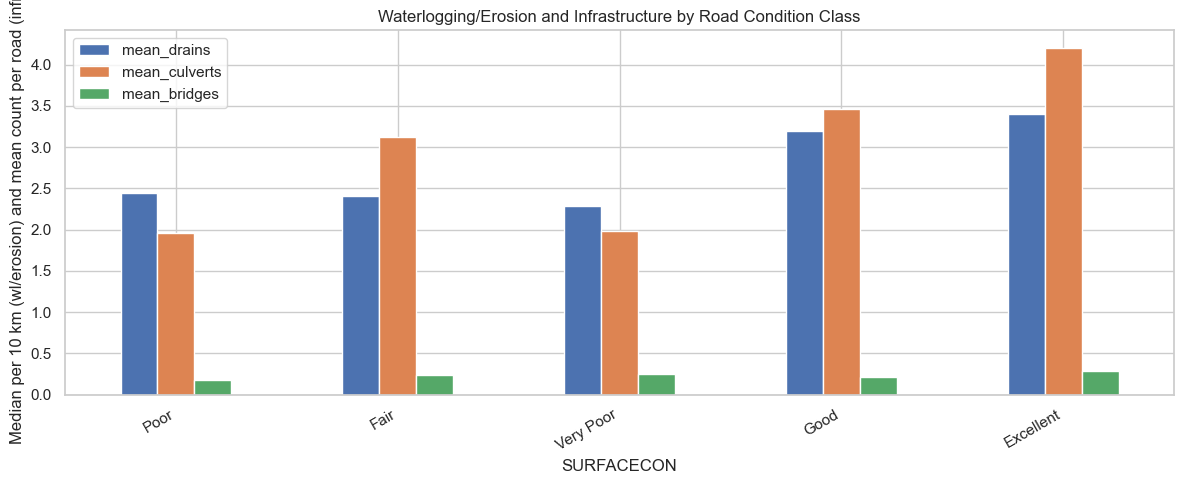

In [17]:
# Same style as previous graph, but safe for current norm_summary columns
order = ["Poor", "Fair", "Very Poor", "Good", "Excellent"]
plot_df = summary_u.reindex(order).copy()

candidate_cols = ["wl_med", "er_med", "mean_drains", "mean_culverts", "mean_bridges"]
plot_cols = [c for c in candidate_cols if c in plot_df.columns]

if not plot_cols:
    raise ValueError(f"No expected columns found. Available columns: {plot_df.columns.tolist()}")

plot_df[plot_cols].plot(kind="bar", figsize=(12,5))
plt.title("Waterlogging/Erosion and Infrastructure by Road Condition Class")
plt.ylabel("Median per 10 km (wl/erosion) and mean count per road (infra)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [18]:
# Build len_km first, then compute length-normalized problem rates
tmp = base_inf_u.copy()

# derive len_km from available network fields
for c in ["SHPLEN", "TOTALLEN"]:
    if c in tmp.columns:
        tmp[c] = pd.to_numeric(tmp[c], errors="coerce")

if "SHPLEN" in tmp.columns and "TOTALLEN" in tmp.columns:
    tmp["len_km"] = tmp["SHPLEN"]
    tmp.loc[tmp["len_km"].isna() | (tmp["len_km"] <= 0), "len_km"] = tmp["TOTALLEN"]
elif "SHPLEN" in tmp.columns:
    tmp["len_km"] = tmp["SHPLEN"]
elif "TOTALLEN" in tmp.columns:
    tmp["len_km"] = tmp["TOTALLEN"]
else:
    raise ValueError("No SHPLEN/TOTALLEN columns found in base_inf_u")

tmp["len_km"] = pd.to_numeric(tmp["len_km"], errors="coerce")
tmp = tmp[tmp["len_km"] > 0].copy()

# ensure problem cols exist
for c in ["Waterlogging", "Erosion", "Landslide"]:
    if c not in tmp.columns:
        tmp[c] = 0
    tmp[c] = pd.to_numeric(tmp[c], errors="coerce").fillna(0)

# per-10km rates
tmp["Waterlogging_per_10km"] = tmp["Waterlogging"] / tmp["len_km"] * 10
tmp["Erosion_per_10km"] = tmp["Erosion"] / tmp["len_km"] * 10
tmp["Landslide_per_10km"] = tmp["Landslide"] / tmp["len_km"] * 10

norm_summary = tmp.groupby("SURFACECON").agg(
    roads_n=("ROADCODE_N", "nunique"),
    wl_med=("Waterlogging_per_10km", "median"),
    wl_iqr=("Waterlogging_per_10km", lambda s: s.quantile(0.75) - s.quantile(0.25)),
    er_med=("Erosion_per_10km", "median"),
    er_iqr=("Erosion_per_10km", lambda s: s.quantile(0.75) - s.quantile(0.25)),
    ls_med=("Landslide_per_10km", "median"),
    ls_iqr=("Landslide_per_10km", lambda s: s.quantile(0.75) - s.quantile(0.25)),
).sort_index()

norm_summary



,roads_n,wl_med,wl_iqr,er_med,er_iqr,ls_med,ls_iqr
SURFACECON,,,,,,,
Excellent,132,0.000000,1.050579,0.000000,2.083068,0.0,0.0
Fair,1496,0.480277,6.405060,1.805383,8.354236,0.0,0.0
Good,592,0.000000,2.633490,0.000000,3.344223,0.0,0.0
Poor,1723,0.746464,6.146284,1.790831,7.958979,0.0,0.0
Very Poor,630,1.018346,7.776832,1.658280,8.667992,0.0,0.0


### Interpretation of length-normalized problem indicators by road condition

This table shows median and IQR values of waterlogging and erosion problem counts normalized per 10 km of road, grouped by `SURFACECON` class.

Key observations:

- **Waterlogging** (`wl_med`) increases as condition worsens:
  - `Excellent`: 0.00
  - `Good`: 0.00
  - `Fair`: 0.48
  - `Poor`: 0.75
  - `Very Poor`: 1.02  
  This indicates roads in worse condition tend to have more waterlogging problems per unit length.

- **Erosion** (`er_med`) is also higher in degraded classes:
  - `Excellent` and `Good`: 0.00
  - `Fair`, `Poor`, `Very Poor`: around 1.66–1.81 per 10 km  
  This suggests erosion is more associated with lower condition classes.

- **Landslide** (`ls_med`, `ls_iqr`) is zero across classes in this subset, so it is not contributing meaningful variation here.

- **IQR values** (`wl_iqr`, `er_iqr`) are large, especially in `Fair`, `Poor`, and `Very Poor`, showing strong variability between roads even within the same condition class.


## Getting Sentinel-2 data for the same roads and time period, then linking to this base_inf_u by ROADCODE_N for analysis of how surface condition relates to spectral indices and their trends over time.

In [19]:
# Cell A — Sanity check existing base table from earlier cells
required_base_cols = [
    "ROADCODE_N", "SURFACECON", "ROADCLASS", "PAVETYPE",
    "drains_n", "culverts_n", "bridges_n", "Waterlogging", "Erosion", "Landslide"
]
missing_base = [c for c in required_base_cols if c not in base_inf_u.columns]
if missing_base:
    raise ValueError(f"Missing in base_inf_u: {missing_base}")

print("base_inf_u rows:", len(base_inf_u))
print("base_inf_u unique ROADCODE_N:", base_inf_u["ROADCODE_N"].nunique())
base_inf_u[["ROADCODE_N", "SURFACECON", "ROADCLASS", "PAVETYPE"]].head()


base_inf_u rows: 4573
base_inf_u unique ROADCODE_N: 4573


,ROADCODE_N,SURFACECON,ROADCLASS,PAVETYPE
0,0101-00061,Very Poor,Trunk C Township,EARTHEN
1,0101-00093,Poor,Trunk C Township,EARTHEN
2,0101-00094,Fair,Trunk C Township,ASPHALT CONCRETE
3,0101-00106,Fair,Trunk C Township,EARTHEN
4,0101-00113,Fair,Trunk C Township,ASPHALT CONCRETE


In [23]:
# Cell B — Load Nigeria S2 CSVs and strip chunk/helper columns
import re
from pathlib import Path
import pandas as pd
import numpy as np

S2_DIR = Path("/Users/miranda/Documents/GitHub/Sentinel-FYP/data/nigeria_s2")
s2_files = sorted(S2_DIR.glob("nigeria_s2_2020_Q*.csv"))
if not s2_files:
    raise FileNotFoundError(f"No nigeria_s2_2020_Q*.csv files found in {S2_DIR}")

dfs = []
for f in s2_files:
    d = pd.read_csv(f)

    # Parse year/quarter from filename as fallback
    m = re.search(r"nigeria_s2_(\d{4})_(Q[1-4])", f.stem)
    if m:
        y_file, q_file = int(m.group(1)), m.group(2)
        if "year" not in d.columns:
            d["year"] = y_file
        if "quarter" not in d.columns:
            d["quarter"] = q_file

    # Drop export helper columns
    drop_cols = [c for c in ["chunk", "chunk_rand", ".geo", "system:index"] if c in d.columns]
    if drop_cols:
        d = d.drop(columns=drop_cols)

    # Normalize key
    d["ROADCODE_N"] = (
        d["ROADCODE_N"].astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)
        .str.upper()
    )

    dfs.append(d)

s2_raw = pd.concat(dfs, ignore_index=True)

print("Loaded files:", [f.name for f in s2_files])
print("s2_raw rows:", len(s2_raw))
print("s2_raw unique ROADCODE_N:", s2_raw["ROADCODE_N"].nunique())
s2_raw.head(3)


Loaded files: ['nigeria_s2_2020_Q1.csv', 'nigeria_s2_2020_Q2.csv', 'nigeria_s2_2020_Q3.csv', 'nigeria_s2_2020_Q4.csv']
s2_raw rows: 63812
s2_raw unique ROADCODE_N: 4573


,B11,B12,B2,B3,B4,B8,BSI,ID,NDBI,NDMI,NDVI,NDWI,ROADCODE,ROADCODE_N,ROADNAME,SURFACECON,quarter,year
0,2681.813790,2091.311445,970.076923,1147.619137,1242.249531,2226.786585,0.101719,18717,0.092455,-0.092455,0.284726,-0.320558,0314-00225,0314-00225,Ikot Abia Idem-Ndiya Etok [Ikono],NaN,Q1,2020
1,4415.000000,3796.000000,1275.000000,1874.000000,2594.000000,3320.000000,0.208032,20183,0.141564,-0.141564,0.122760,-0.278398,2017-00229,2017-00229,Kwasangwami Babawa,NaN,Q1,2020
2,4472.181308,3409.769576,864.403171,1342.141173,2066.927449,2947.949761,0.263417,2058,0.205485,-0.205485,0.176261,-0.374858,2216-00238,2216-00238,Dirin Daji - Makuku,NaN,Q1,2020


In [24]:
# Cell C — Clean S2 numeric fields and aggregate to one row per road-quarter
idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
band_cols = ["B2", "B3", "B4", "B8", "B11", "B12"]
num_cols = [c for c in idx_cols + band_cols if c in s2_raw.columns]

for c in num_cols + ["year"]:
    s2_raw[c] = pd.to_numeric(s2_raw[c], errors="coerce")

s2_raw["quarter"] = s2_raw["quarter"].astype(str).str.strip().str.upper()
s2_raw = s2_raw[s2_raw["quarter"].isin(["Q1", "Q2", "Q3", "Q4"])].copy()

# Drop rows where all core indices are missing
s2_raw = s2_raw.dropna(subset=idx_cols, how="all").copy()

# Deduplicate road-quarter rows (if repeated from chunking), keep mean
agg_dict = {c: "mean" for c in num_cols}
for c in ["SURFACECON", "ROADCODE", "ROADNAME", "ID"]:
    if c in s2_raw.columns:
        agg_dict[c] = "first"

s2_q = (
    s2_raw.groupby(["ROADCODE_N", "year", "quarter"], as_index=False)
    .agg(agg_dict)
)

print("s2_q rows:", len(s2_q))
print("s2_q unique roads:", s2_q["ROADCODE_N"].nunique())
s2_q.head(3)


s2_q rows: 13456
s2_q unique roads: 4570


,ROADCODE_N,year,quarter,NDVI,NDMI,NDBI,NDWI,BSI,B2,B3,B4,B8,B11,B12,SURFACECON,ROADCODE,ROADNAME,ID
0,0101-00061,2020,Q1,0.082302,-0.093375,0.093375,-0.136370,0.107549,1209.999055,1403.551735,1566.261640,1847.771149,2232.079490,2156.768922,Very Poor,0101-00061,Aba Owerri Road-Njoku Road,13452
1,0101-00093,2020,Q1,0.166939,-0.093255,0.093255,-0.225672,0.113112,1116.307188,1338.688864,1520.484985,2114.747720,2559.397462,2338.433625,Poor,0101-00093,Gasline rd by Umuikpo rd,13488
2,0101-00094,2020,Q1,0.109834,-0.101962,0.101962,-0.156926,0.108531,1195.487975,1380.945659,1521.511296,1900.278911,2334.304849,2218.747405,Fair,0101-00094,Umuimo-Ayabaumueze-Okpuumuobo rd-Umuimo rd,13496


In [25]:
# Cell D — Merge S2 with your existing local infrastructure/problem table
base_join = base_inf_u.copy()
base_join["ROADCODE_N"] = (
    base_join["ROADCODE_N"].astype(str)
    .str.strip()
    .str.replace(r"\s+", "", regex=True)
    .str.upper()
)
base_join = base_join.drop_duplicates("ROADCODE_N").copy()

nigeria_s2_full = s2_q.merge(
    base_join[
        [
            "ROADCODE_N", "SURFACECON", "ROADCLASS", "PAVETYPE",
            "drains_n", "culverts_n", "bridges_n",
            "Waterlogging", "Erosion", "Landslide"
        ]
    ],
    on="ROADCODE_N",
    how="left",
    suffixes=("", "_base")
)

# Prefer condition from base table where available
if "SURFACECON_base" in nigeria_s2_full.columns:
    nigeria_s2_full["SURFACECON"] = nigeria_s2_full["SURFACECON_base"].fillna(nigeria_s2_full.get("SURFACECON"))
    nigeria_s2_full = nigeria_s2_full.drop(columns=["SURFACECON_base"])

print("nigeria_s2_full rows:", len(nigeria_s2_full))
print("matched rows with ROADCLASS:", nigeria_s2_full["ROADCLASS"].notna().sum())
print("unique matched roads:", nigeria_s2_full.loc[nigeria_s2_full["ROADCLASS"].notna(), "ROADCODE_N"].nunique())
nigeria_s2_full.head(5)


nigeria_s2_full rows: 13456
matched rows with ROADCLASS: 13456
unique matched roads: 4570


,ROADCODE_N,year,quarter,NDVI,NDMI,NDBI,NDWI,BSI,B2,B3,...,ROADNAME,ID,ROADCLASS,PAVETYPE,drains_n,culverts_n,bridges_n,Waterlogging,Erosion,Landslide
0,0101-00061,2020,Q1,0.082302,-0.093375,0.093375,-0.136370,0.107549,1209.999055,1403.551735,...,Aba Owerri Road-Njoku Road,13452,Trunk C Township,EARTHEN,3.0,0.0,0.0,1.0,0.0,0.0
1,0101-00093,2020,Q1,0.166939,-0.093255,0.093255,-0.225672,0.113112,1116.307188,1338.688864,...,Gasline rd by Umuikpo rd,13488,Trunk C Township,EARTHEN,1.0,0.0,0.0,1.0,1.0,0.0
2,0101-00094,2020,Q1,0.109834,-0.101962,0.101962,-0.156926,0.108531,1195.487975,1380.945659,...,Umuimo-Ayabaumueze-Okpuumuobo rd-Umuimo rd,13496,Trunk C Township,ASPHALT CONCRETE,3.0,1.0,0.0,0.0,0.0,0.0
3,0101-00106,2020,Q1,0.150019,-0.101969,0.101969,-0.205371,0.115750,1181.142049,1395.223471,...,Isiguzo Road-Chilaka Ahunanya Road,13553,Trunk C Township,EARTHEN,5.0,3.0,0.0,0.0,0.0,0.0
4,0101-00113,2020,Q1,0.117928,-0.086608,0.086608,-0.171470,0.103782,1168.326374,1363.638794,...,Uratta Junction-PH Express,13578,Trunk C Township,ASPHALT CONCRETE,1.0,2.0,0.0,2.0,7.0,0.0


In [26]:
# Cell E — Save parquet (partitioned by year) for future time-series extension
from pathlib import Path

OUT_DIR = Path("/Users/miranda/Documents/GitHub/Sentinel-FYP/data/nigeria_parquet")
OUT_DIR.mkdir(parents=True, exist_ok=True)

nigeria_s2_full.to_parquet(OUT_DIR, index=False, partition_cols=["year"])
print("Saved partitioned parquet to:", OUT_DIR)


Saved partitioned parquet to: /Users/miranda/Documents/GitHub/Sentinel-FYP/data/nigeria_parquet


In [27]:
# Cell F — Quick baseline summary + quarterly plots by condition class
import seaborn as sns
import matplotlib.pyplot as plt

plot_df = nigeria_s2_full.copy()
plot_df = plot_df[plot_df["SURFACECON"].isin(["Excellent", "Good", "Fair", "Poor", "Very Poor"])].copy()

# Summary table
summary_s2 = (
    plot_df.groupby("SURFACECON")[["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]]
    .agg(["mean", "std", "median"])
)
summary_s2


NDVI                          NDMI                      \
                mean       std    median      mean       std    median   
SURFACECON                                                               
Excellent   0.266486  0.120971  0.249841 -0.078684  0.088479 -0.090895   
Fair        0.271228  0.135294  0.246459 -0.079678  0.096517 -0.104536   
Good        0.263694  0.120907  0.247400 -0.078548  0.089417 -0.091418   
Poor        0.324632  0.149183  0.305343 -0.049489  0.104272 -0.065427   
Very Poor   0.313923  0.148411  0.291025 -0.052793  0.103346 -0.063203   

                NDBI                          NDWI                      \
                mean       std    median      mean       std    median   
SURFACECON                                                               
Excellent   0.078684  0.088479  0.090895 -0.350735  0.085559 -0.340305   
Fair        0.079678  0.096517  0.104536 -0.367637  0.088305 -0.357032   
Good        0.078548  0.089417  0.091418 -0.346309  0.084765 -0.337115   
Poor        0.049489  0.104272  0.065427 -0.390350  0.104562 -0.386726   
Very Poor   0.052793  0.103346  0.063203 -0.382805  0.102791 -0.372917   

                 BSI                      
                mean       std    median  
SURFACECON                                
Excellent   0.124260  0.091387  0.141386  
Fair        0.132111  0.097887  0.159477  
Good        0.123503  0.092303  0.135329  
Poor        0.094210  0.105039  0.104186  
Very Poor   0.096883  0.107083  0.102369

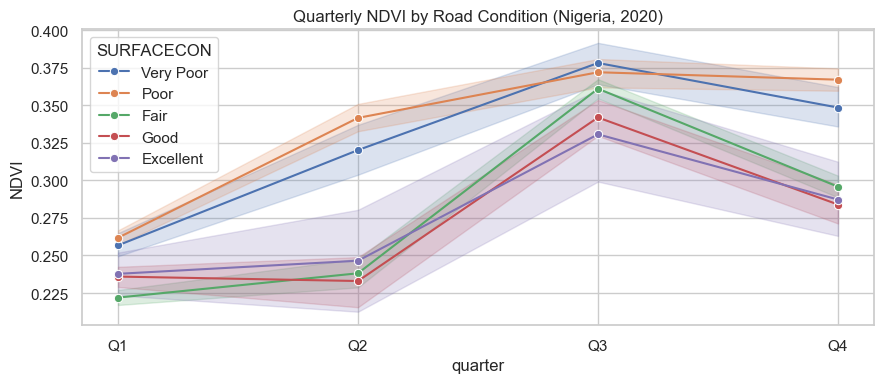

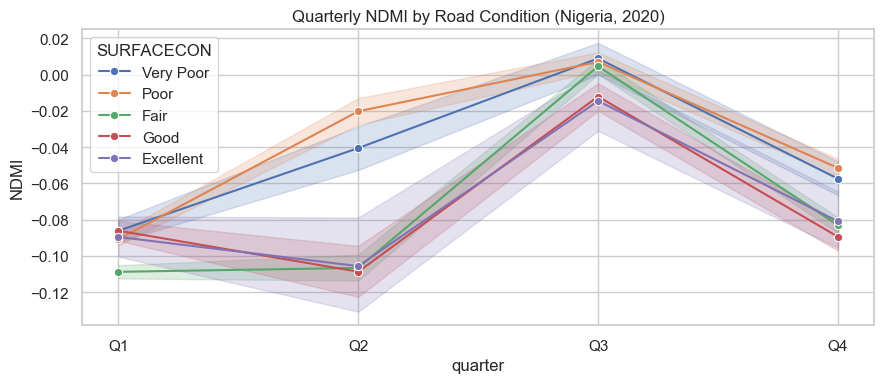

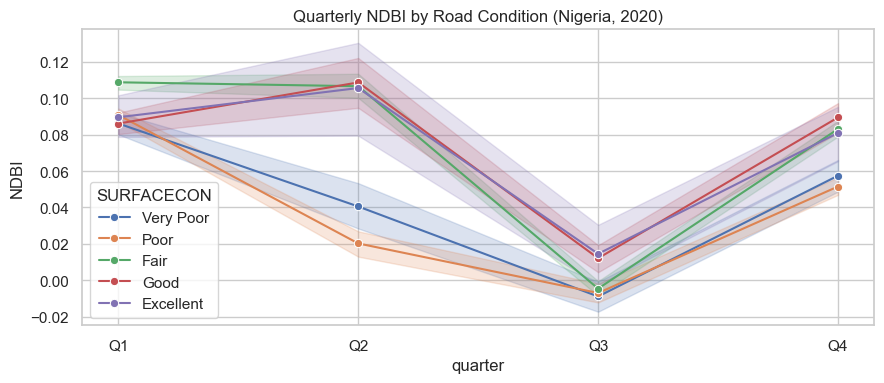

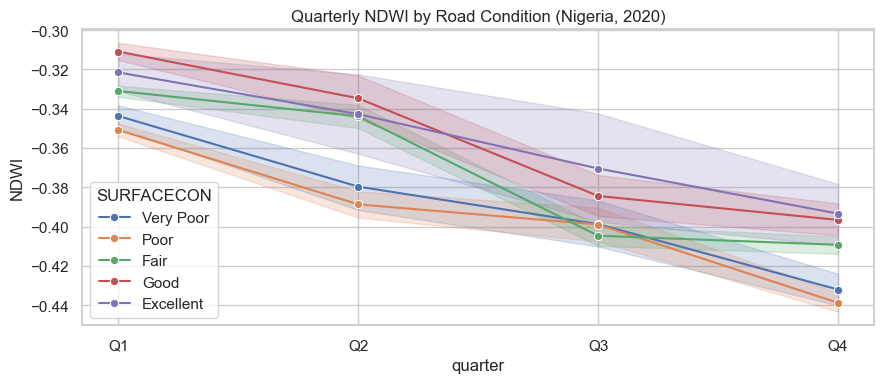

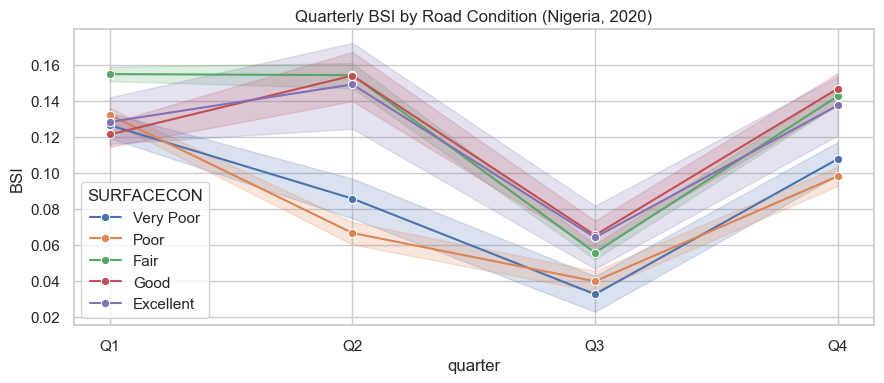

In [28]:
# Cell G — Quarterly trend plots (2020)
order_q = ["Q1", "Q2", "Q3", "Q4"]
plot_df["quarter"] = pd.Categorical(plot_df["quarter"], categories=order_q, ordered=True)

for feat in ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]:
    plt.figure(figsize=(9, 4))
    sns.lineplot(
        data=plot_df,
        x="quarter",
        y=feat,
        hue="SURFACECON",
        estimator="mean",
        marker="o"
    )
    plt.title(f"Quarterly {feat} by Road Condition (Nigeria, 2020)")
    plt.tight_layout()
    plt.show()


In [29]:
# Cell 1 — Prep analysis table
import pandas as pd
import numpy as np

idx_cols = ["NDVI", "NDMI", "NDBI", "NDWI", "BSI"]
cat_cols = ["SURFACECON", "PAVETYPE", "ROADCLASS"]

dfc = nigeria_s2_full.copy()

# keep only rows with indices + key categorical fields
for c in idx_cols:
    dfc[c] = pd.to_numeric(dfc[c], errors="coerce")

for c in cat_cols:
    dfc[c] = dfc[c].astype("string").str.strip()

dfc = dfc.dropna(subset=idx_cols + ["SURFACECON"]).copy()

print("Rows for correlation analysis:", len(dfc))
dfc[idx_cols + cat_cols].head()


Rows for correlation analysis: 13456


,NDVI,NDMI,NDBI,NDWI,BSI,SURFACECON,PAVETYPE,ROADCLASS
0,0.082302,-0.093375,0.093375,-0.136370,0.107549,Very Poor,EARTHEN,Trunk C Township
1,0.166939,-0.093255,0.093255,-0.225672,0.113112,Poor,EARTHEN,Trunk C Township
2,0.109834,-0.101962,0.101962,-0.156926,0.108531,Fair,ASPHALT CONCRETE,Trunk C Township
3,0.150019,-0.101969,0.101969,-0.205371,0.115750,Fair,EARTHEN,Trunk C Township
4,0.117928,-0.086608,0.086608,-0.171470,0.103782,Fair,ASPHALT CONCRETE,Trunk C Township


In [30]:
# Cell 2 — Ordinal correlation: road condition vs indices
# (maps condition to order: Very Poor < Poor < Fair < Good < Excellent)
from scipy.stats import spearmanr, kendalltau

cond_order = {
    "Very Poor": 1,
    "Poor": 2,
    "Fair": 3,
    "Good": 4,
    "Excellent": 5
}

tmp = dfc[dfc["SURFACECON"].isin(cond_order.keys())].copy()
tmp["cond_ord"] = tmp["SURFACECON"].map(cond_order).astype(float)

rows = []
for col in idx_cols:
    x = tmp[col].astype(float)
    y = tmp["cond_ord"]
    m = x.notna() & y.notna()
    rho, p_rho = spearmanr(x[m], y[m])
    tau, p_tau = kendalltau(x[m], y[m])
    rows.append({
        "index": col,
        "spearman_rho": rho,
        "spearman_p": p_rho,
        "kendall_tau": tau,
        "kendall_p": p_tau,
        "n": int(m.sum())
    })

cond_corr = pd.DataFrame(rows).sort_values("spearman_rho", ascending=False)
cond_corr


,index,spearman_rho,spearman_p,kendall_tau,kendall_p,n
3,NDWI,0.148271,5.268113e-67,0.112603,3.472914e-67,13456
4,BSI,0.144917,4.644115e-64,0.109150,3.066524e-63,13456
2,NDBI,0.126040,8.944178e-49,0.094611,5.803485e-48,13456
1,NDMI,-0.126040,8.944178e-49,-0.094611,5.803485e-48,13456
0,NDVI,-0.161752,1.488038e-79,-0.121136,1.840538e-77,13456


In [31]:
# Cell 3 — Effect size (eta^2): how strongly each categorical variable explains each index
# Works for SURFACECON, PAVETYPE, ROADCLASS
def eta_squared(df, y_col, g_col):
    t = df[[y_col, g_col]].dropna().copy()
    if t[g_col].nunique() < 2:
        return np.nan, 0, 0

    grand = t[y_col].mean()
    groups = t.groupby(g_col)[y_col]
    ss_between = sum(len(g) * (g.mean() - grand) ** 2 for _, g in groups)
    ss_total = ((t[y_col] - grand) ** 2).sum()
    eta2 = ss_between / ss_total if ss_total > 0 else np.nan
    return eta2, t[g_col].nunique(), len(t)

effects = []
for g in ["SURFACECON", "PAVETYPE", "ROADCLASS"]:
    for y in idx_cols:
        e, k, n = eta_squared(dfc, y, g)
        effects.append({
            "group_var": g,
            "index": y,
            "eta_squared": e,
            "n_groups": k,
            "n_rows": n
        })

eta_df = pd.DataFrame(effects).sort_values(["group_var", "eta_squared"], ascending=[True, False])
eta_df


,group_var,index,eta_squared,n_groups,n_rows
9,PAVETYPE,BSI,0.050996,10,13456
6,PAVETYPE,NDMI,0.036907,10,13456
7,PAVETYPE,NDBI,0.036907,10,13456
5,PAVETYPE,NDVI,0.033760,10,13456
8,PAVETYPE,NDWI,0.031961,10,13456
14,ROADCLASS,BSI,0.070708,5,13456
10,ROADCLASS,NDVI,0.037648,5,13456
11,ROADCLASS,NDMI,0.037610,5,13456
12,ROADCLASS,NDBI,0.037610,5,13456
13,ROADCLASS,NDWI,0.000651,5,13456


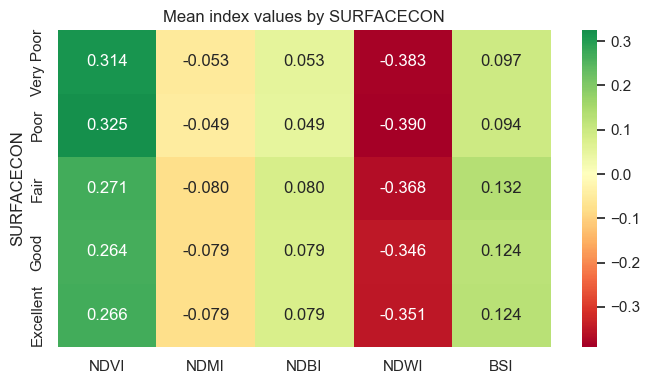

,NDVI,NDMI,NDBI,NDWI,BSI
SURFACECON,,,,,
Very Poor,0.313923,-0.052793,0.052793,-0.382805,0.096883
Poor,0.324632,-0.049489,0.049489,-0.390350,0.094210
Fair,0.271228,-0.079678,0.079678,-0.367637,0.132111
Good,0.263694,-0.078548,0.078548,-0.346309,0.123503
Excellent,0.266486,-0.078684,0.078684,-0.350735,0.124260


In [32]:
# Cell 4 — Heatmap: mean index by road condition class
import seaborn as sns
import matplotlib.pyplot as plt

cond_keep = ["Very Poor", "Poor", "Fair", "Good", "Excellent"]
hdf = (
    dfc[dfc["SURFACECON"].isin(cond_keep)]
    .groupby("SURFACECON")[idx_cols]
    .mean()
    .reindex(cond_keep)
)

plt.figure(figsize=(7, 4))
sns.heatmap(hdf, annot=True, fmt=".3f", cmap="RdYlGn", center=0)
plt.title("Mean index values by SURFACECON")
plt.tight_layout()
plt.show()

hdf


What that implies:

Poor roads in this dataset appear to be in more vegetated corridors (NDVI higher), not necessarily more built-up areas.
Better roads appear in more built-up / bare-material contexts (NDBI, BSI higher).

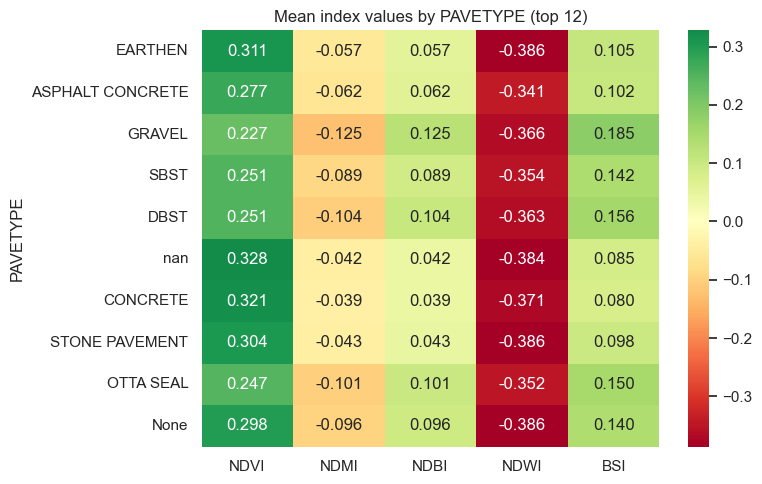

,NDVI,NDMI,NDBI,NDWI,BSI
PAVETYPE,,,,,
EARTHEN,0.311114,-0.057001,0.057001,-0.386252,0.104572
ASPHALT CONCRETE,0.276672,-0.061709,0.061709,-0.341118,0.101778
GRAVEL,0.226503,-0.125001,0.125001,-0.365895,0.185452
SBST,0.251455,-0.089410,0.089410,-0.353593,0.142437
DBST,0.251165,-0.103617,0.103617,-0.362709,0.155540
nan,0.327748,-0.042331,0.042331,-0.384099,0.084550
CONCRETE,0.320949,-0.039446,0.039446,-0.371087,0.080240
STONE PAVEMENT,0.303634,-0.043262,0.043262,-0.386140,0.097804
OTTA SEAL,0.246930,-0.101242,0.101242,-0.351763,0.149843


In [33]:
# Cell 5 — Heatmap: mean index by pavement type (top 12 by count)
pave_counts = dfc["PAVETYPE"].value_counts(dropna=False)
top_pave = pave_counts.head(12).index

pdf = (
    dfc[dfc["PAVETYPE"].isin(top_pave)]
    .groupby("PAVETYPE")[idx_cols]
    .mean()
    .loc[top_pave]
)

plt.figure(figsize=(8, 5))
sns.heatmap(pdf, annot=True, fmt=".3f", cmap="RdYlGn", center=0)
plt.title("Mean index values by PAVETYPE (top 12)")
plt.tight_layout()
plt.show()

pdf
